# DD2 Training + Metrics + Plots

Этот ноутбук запускает:
1. обучение PPO,
2. оценку моделей/чекпоинтов,
3. сбор метрик в DataFrame,
4. построение графиков качества обучения.

Перед запуском убедись, что активировано правильное Python-окружение с CUDA (`torch.cuda.is_available() == True`).

## Активация правильного окружения (Windows + PowerShell)

Перед запуском ячеек выполни в терминале:

```powershell
cd "D:\RL DD"
.\.venv\Scripts\Activate.ps1
python -c "import sys; print(sys.executable)"
```

Ожидается путь вида: `D:\RL DD\.venv\Scripts\python.exe`.

Если в ячейке «Проверка CUDA» видно `torch ... +cpu`, чаще всего выбран **не тот** kernel (не этот `.venv`) или в этом Python стоит CPU-сборка — ячейка подскажет команды `pip` для текущего интерпретатора.

Если `venv` еще не создан:

```powershell
cd "D:\RL DD"
python -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install --upgrade pip
```

Для Jupyter kernel в этом окружении:

```powershell
python -m pip install ipykernel
python -m ipykernel install --user --name rl-dd-venv --display-name "Python (RL DD venv)"
```

После этого выбери в ноутбуке kernel **Python (RL DD venv)**.

## Зависимости ноутбука

Сначала выполни ячейку ниже: `pip install -r requirements.txt` в **тот же** Python, что выбран как kernel (корень проекта — текущая рабочая папка ноутбука). Затем снова запусти ячейку с импортами.

In [1]:
# Установка зависимостей из requirements.txt (включая sb3-contrib, stable-baselines3, …)
import subprocess
import sys
from pathlib import Path

_root = Path.cwd()
_req = _root / "requirements.txt"
if not _req.is_file():
    raise FileNotFoundError(f"Нет {_req}. Открой ноутбук из корня проекта.")

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "--upgrade", "-r", str(_req)],
    cwd=str(_root),
)
print("OK:", sys.executable)
print("requirements:", _req.resolve())

OK: d:\RL DD\.venv\Scripts\python.exe
requirements: D:\RL DD\requirements.txt


In [2]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "scripts").exists():
    raise RuntimeError("Открой ноутбук из корня проекта D:/RL DD")

RUNS = ROOT / "runs"
RUNS.mkdir(exist_ok=True)

print("python:", sys.executable)
print("root:", ROOT)

python: d:\RL DD\.venv\Scripts\python.exe
root: d:\RL DD


In [3]:
# Внутренняя проверка: ноутбук запущен в нужном Python
import sys
from pathlib import Path

expected = Path.cwd() / ".venv" / "Scripts" / "python.exe"
actual = Path(sys.executable)
print("actual:", actual)
print("expected:", expected)
if expected.exists() and actual.resolve() != expected.resolve():
    print("WARNING: ноутбук запущен не в .venv. Переключи kernel на 'Python (RL DD venv)'.")
else:
    print("OK: используется правильное окружение или .venv не создан локально.")

actual: d:\RL DD\.venv\Scripts\python.exe
expected: d:\RL DD\.venv\Scripts\python.exe
OK: используется правильное окружение или .venv не создан локально.


In [4]:
# Проверка CUDA (ожидается kernel = .venv проекта)
import sys
from pathlib import Path

import torch

venv_py = Path.cwd() / ".venv" / "Scripts" / "python.exe"
print("sys.executable:", sys.executable)
print("cwd:", Path.cwd())
print("torch:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

if venv_py.is_file() and Path(sys.executable).resolve() != venv_py.resolve():
    print(
        "\n>>> Kernel не из .venv этого проекта. Выбери интерпретатор",
        venv_py,
        "(в Cursor: kernel / Select Interpreter).",
        sep="\n",
    )

if "+cpu" in torch.__version__.lower() or not torch.cuda.is_available():
    cu = "https://download.pytorch.org/whl/cu128"
    exe = sys.executable
    print("\n--- Установи CUDA-сборку для ТЕКУЩЕГО kernel (PowerShell, один раз):\n")
    print(f'& "{exe}" -m pip uninstall -y torch torchvision torchaudio')
    print(f'& "{exe}" -m pip install -U torch torchvision torchaudio --index-url {cu}')
    print("\nПотом Kernel → Restart и снова эта ячейка. Если cu128 не подойдёт — замени на .../whl/cu126")


sys.executable: d:\RL DD\.venv\Scripts\python.exe
cwd: d:\RL DD
torch: 2.11.0+cu128
torch.version.cuda: 12.8
cuda available: True
gpu: NVIDIA GeForce RTX 5060 Ti


## PyTorch с GPU (если видишь `2.x.x+cpu` и `cuda available: False`)

После `pip install -r requirements.txt` часто ставится **CPU-only** `torch` (зависимость SB3). Нужна отдельная установка **CUDA-сборки** с индекса PyTorch.

1. Выполни ячейку ниже **один раз** (флаг `INSTALL_GPU_TORCH = True`).
2. **Kernel → Restart** (обязательно, иначе в памяти останется старый torch).
3. Снова запусти ячейку «Проверка CUDA».

Если `cu128` не подойдёт, в ячейке смени `CUDA_INDEX_URL` на `https://download.pytorch.org/whl/cu126`.

In [5]:
def run(cmd: list[str]):
    print("$", " ".join(cmd))
    completed = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True)
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print(completed.stderr, end="")
    if completed.returncode != 0:
        raise RuntimeError(f"Command failed: {completed.returncode}")
    return completed


def evaluate_model(model_path: Path, episodes: int = 200, seed: int = 17, out_json: Path | None = None):
    if out_json is None:
        out_json = RUNS / "last_eval.json"
    cmd = [
        sys.executable,
        str(ROOT / "scripts" / "evaluate.py"),
        "--model", str(model_path),
        "--episodes", str(episodes),
        "--seed", str(seed),
        "--out-json", str(out_json),
    ]
    run(cmd)
    return json.loads(out_json.read_text(encoding="utf-8"))

## 1) Запуск обучения

Измени параметры ниже и запусти ячейку.

In [6]:
# Параметры обучения
steps = 1_000_000  # было 300k — слабые holdout (elite_swarm) требуют дольше куррикулума
n_envs = 8
device = "cuda"          # auto | cuda | cpu
use_dummy_vec = True      # для Windows обычно True
learning_rate = 2.5e-4
ent_coef = 0.01
net_arch = "384,384"    # совпадает с дефолтом train.py
n_steps = 1024
batch_size = 256
lr_end_ratio = 0.08       # линейный decay LR; 1.0 = без decay
out_model = RUNS / "dd2_ppo_notebook.zip"
out_meta = RUNS / "dd2_ppo_notebook_meta.json"

cmd = [
    sys.executable,
    str(ROOT / "scripts" / "train.py"),
    "--steps", str(steps),
    "--n-envs", str(n_envs),
    "--device", device,
    "--learning-rate", str(learning_rate),
    "--ent-coef", str(ent_coef),
    "--net-arch", net_arch,
    "--n-steps", str(n_steps),
    "--batch-size", str(batch_size),
    "--lr-end-ratio", str(lr_end_ratio),
    "--out", str(out_model),
    "--run-meta-out", str(out_meta),
]
if use_dummy_vec:
    cmd.append("--use-dummy-vec")

run(cmd)
print("saved:", out_model)

$ d:\RL DD\.venv\Scripts\python.exe d:\RL DD\scripts\train.py --steps 300000 --n-envs 8 --device cuda --learning-rate 0.00025 --ent-coef 0.01 --net-arch 256,256 --out d:\RL DD\runs\dd2_ppo_notebook.zip --run-meta-out d:\RL DD\runs\dd2_ppo_notebook_meta.json --use-dummy-vec
training_device=cuda
Using cuda device
Logging to runs/tb/MaskablePPO_13

   0% ------------------------------- 0/300,000  [ 0:00:00 < -:--:-- , ? it/s ]
   0% ------------------------------- 0/300,000  [ 0:00:00 < -:--:-- , ? it/s ]
   0% ------------------------------- 8/300,000  [ 0:00:00 < -:--:-- , ? it/s ]
   0% ------------------------- 280/300,000  [ 0:00:00 < 0:01:43 , 2,925 it/s ]
   0% ------------------------- 560/300,000  [ 0:00:00 < 0:01:51 , 2,719 it/s ]
   0% ------------------------- 824/300,000  [ 0:00:00 < 0:01:49 , 2,757 it/s ]
   0% ----------------------- 1,064/300,000  [ 0:00:00 < 0:01:55 , 2,601 it/s ]
   0% ----------------------- 1,336/300,000  [ 0:00:00 < 0:01:53 , 2,656 it/s ]
   1% ------

## 2) Оценка лучшей модели и текущей модели

In [7]:
best_model = RUNS / "best" / "best_model.zip"
models_to_eval = []
if best_model.exists():
    models_to_eval.append(best_model)
if out_model.exists():
    models_to_eval.append(out_model)

rows = []
for i, m in enumerate(models_to_eval):
    out_json = RUNS / f"eval_{m.stem}_{i}.json"
    result = evaluate_model(m, episodes=200, seed=17, out_json=out_json)
    s = result["summary"]
    rows.append({
        "model": str(m),
        "win_rate": s["win_rate"],
        "mean_reward": s["mean_reward"],
        "mean_steps": s["mean_steps"],
        "survival_rate": s["survival_rate"],
        "json": str(out_json),
    })

df_models = pd.DataFrame(rows)
df_models

$ d:\RL DD\.venv\Scripts\python.exe d:\RL DD\scripts\evaluate.py --model d:\RL DD\runs\best\best_model.zip --episodes 200 --seed 17 --out-json d:\RL DD\runs\eval_best_model_0.json
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
win_rate=66.50% mean_reward=8.660 mean_steps=19.41 survival_rate=61.25%
encounter_breakdown:
  holdout_double_cultist: win_rate=100.00% mean_reward=36.503 mean_steps=20.30 survival_rate=100.00%
  holdout_double_ghoul: win_rate=100.00% mean_reward=32.514 mean_steps=21.00 survival_rate=91.25%
  holdout_elite_pair: win_rate=32.50% mean_reward=-17.331 mean_steps=20.40 survival_rate=17.50%
  holdout_elite_swarm: win_rate=0.00% mean_reward=-43.754 mean_steps=14.53 survival_rate=0.00%
  holdout_mix_wave: win_rate=100.00% mean_reward=35.367 mean_steps=20.85 survival_rate=97.50%
wrote_metrics_json=d:\RL DD\runs\eval_best_model_0.json

$ d:\RL DD\.venv\Scripts\python.exe d:\RL DD\scripts\evaluate.py --model d:\RL DD\runs\dd2_ppo_notebook.zip -

,model,win_rate,mean_reward,mean_steps,survival_rate,json
0,d:\RL DD\runs\best\best_model.zip,0.665,8.659933,19.415,0.6125,d:\RL DD\runs\eval_best_model_0.json
1,d:\RL DD\runs\dd2_ppo_notebook.zip,0.665,8.659933,19.415,0.6125,d:\RL DD\runs\eval_dd2_ppo_notebook_1.json


## 3) Сбор метрик по чекпоинтам

Эта ячейка прогонит `evaluate.py` по всем `runs/checkpoints/*.zip` и соберет историю качества.

In [8]:
ckpt_dir = RUNS / "checkpoints"
ckpts = sorted(ckpt_dir.glob("*.zip"))

hist_rows = []
for ckpt in ckpts:
    out_json = RUNS / "eval_checkpoints" / f"{ckpt.stem}.json"
    out_json.parent.mkdir(parents=True, exist_ok=True)
    result = evaluate_model(ckpt, episodes=100, seed=17, out_json=out_json)
    step = None
    # ожидание формата rl_model_50000_steps.zip
    parts = ckpt.stem.split("_")
    for p in parts:
        if p.isdigit():
            step = int(p)
            break
    s = result["summary"]
    hist_rows.append({
        "checkpoint": ckpt.name,
        "step": step,
        "win_rate": s["win_rate"],
        "mean_reward": s["mean_reward"],
        "mean_steps": s["mean_steps"],
        "survival_rate": s["survival_rate"],
    })

df_hist = pd.DataFrame(hist_rows).sort_values(by=["step", "checkpoint"], na_position="last")
df_hist.head(), len(df_hist)

$ d:\RL DD\.venv\Scripts\python.exe d:\RL DD\scripts\evaluate.py --model d:\RL DD\runs\checkpoints\rl_model_1000000_steps.zip --episodes 100 --seed 17 --out-json d:\RL DD\runs\eval_checkpoints\rl_model_1000000_steps.json
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
win_rate=66.00% mean_reward=8.368 mean_steps=19.49 survival_rate=60.50%
encounter_breakdown:
  holdout_double_cultist: win_rate=100.00% mean_reward=36.592 mean_steps=20.25 survival_rate=100.00%
  holdout_double_ghoul: win_rate=100.00% mean_reward=32.055 mean_steps=21.10 survival_rate=90.00%
  holdout_elite_pair: win_rate=30.00% mean_reward=-17.878 mean_steps=20.50 survival_rate=17.50%
  holdout_elite_swarm: win_rate=0.00% mean_reward=-43.839 mean_steps=14.60 survival_rate=0.00%
  holdout_mix_wave: win_rate=100.00% mean_reward=34.908 mean_steps=21.00 survival_rate=95.00%
wrote_metrics_json=d:\RL DD\runs\eval_checkpoints\rl_model_1000000_steps.json

$ d:\RL DD\.venv\Scripts\python.exe d:\RL DD\s

(                   checkpoint    step  win_rate  mean_reward  mean_steps  \
 10   rl_model_50000_steps.zip   50000      0.66     8.367509       19.49   
 1   rl_model_100000_steps.zip  100000      0.66     8.367509       19.49   
 2   rl_model_150000_steps.zip  150000      0.66     8.367509       19.49   
 3   rl_model_200000_steps.zip  200000      0.66     8.367509       19.49   
 4   rl_model_250000_steps.zip  250000      0.66     8.367509       19.49   
 
     survival_rate  
 10          0.605  
 1           0.605  
 2           0.605  
 3           0.605  
 4           0.605  ,
 20)

## 4) Графики обучения

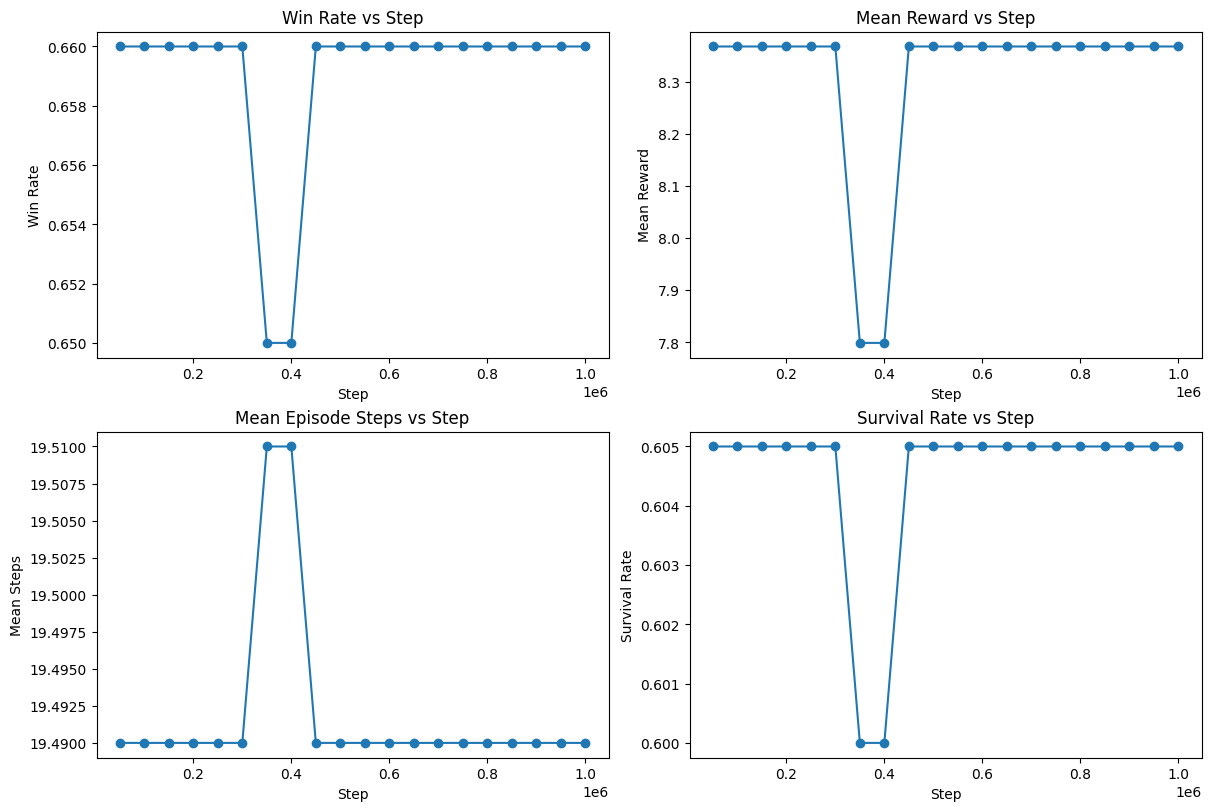

In [9]:
if len(df_hist) == 0:
    print("Нет чекпоинтов для построения графиков.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

    axes[0, 0].plot(df_hist["step"], df_hist["win_rate"], marker="o")
    axes[0, 0].set_title("Win Rate vs Step")
    axes[0, 0].set_xlabel("Step")
    axes[0, 0].set_ylabel("Win Rate")

    axes[0, 1].plot(df_hist["step"], df_hist["mean_reward"], marker="o")
    axes[0, 1].set_title("Mean Reward vs Step")
    axes[0, 1].set_xlabel("Step")
    axes[0, 1].set_ylabel("Mean Reward")

    axes[1, 0].plot(df_hist["step"], df_hist["mean_steps"], marker="o")
    axes[1, 0].set_title("Mean Episode Steps vs Step")
    axes[1, 0].set_xlabel("Step")
    axes[1, 0].set_ylabel("Mean Steps")

    axes[1, 1].plot(df_hist["step"], df_hist["survival_rate"], marker="o")
    axes[1, 1].set_title("Survival Rate vs Step")
    axes[1, 1].set_xlabel("Step")
    axes[1, 1].set_ylabel("Survival Rate")

    plt.show()

,encounter,episodes,win_rate,mean_reward,mean_steps,survival_rate
3,holdout_elite_swarm,20.0,0.0,-43.838948,14.60,0.000
2,holdout_elite_pair,20.0,0.3,-17.878132,20.50,0.175
1,holdout_double_ghoul,20.0,1.0,32.055444,21.10,0.900
0,holdout_double_cultist,20.0,1.0,36.591597,20.25,1.000
4,holdout_mix_wave,20.0,1.0,34.907583,21.00,0.950


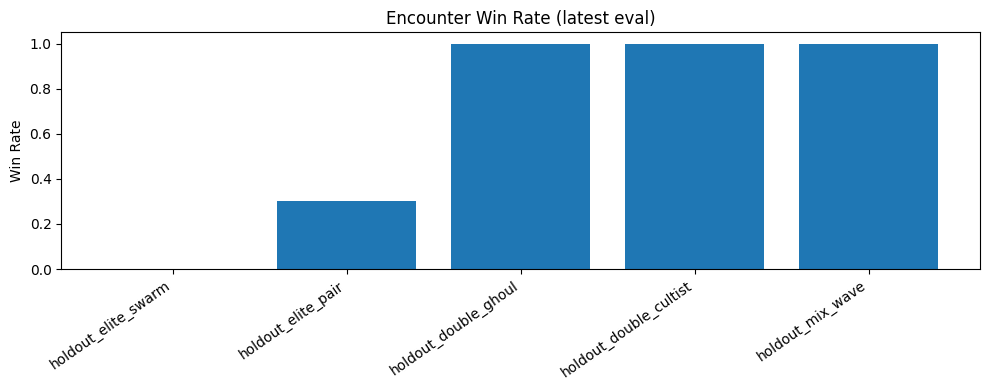

In [10]:
# Детальный breakdown по сложным encounter из последней оценки
# (берется любой json из предыдущих eval ячеек)
latest_json = None
candidates = sorted((RUNS / "eval_checkpoints").glob("*.json"))
if candidates:
    latest_json = candidates[-1]

if latest_json is None:
    print("Нет breakdown JSON для отображения.")
else:
    payload = json.loads(latest_json.read_text(encoding="utf-8"))
    enc_rows = []
    for encounter_id, rec in payload.get("encounters", {}).items():
        enc_rows.append({"encounter": encounter_id, **rec})
    df_enc = pd.DataFrame(enc_rows).sort_values("win_rate")
    display(df_enc)

    plt.figure(figsize=(10, 4))
    plt.bar(df_enc["encounter"], df_enc["win_rate"])
    plt.xticks(rotation=35, ha="right")
    plt.title("Encounter Win Rate (latest eval)")
    plt.ylabel("Win Rate")
    plt.tight_layout()
    plt.show()